# Air Quality

## Description

- Air Quality : Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer.

- The dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors embedded in an Air Quality Chemical Multisensor Device.
- The device was located on the field in a significantly polluted area, at road level,within an Italian city.
- Data were recorded from March 2004 to February 2005 (one year)representing the longest freely available recordings of on field deployed air quality chemical sensor devices responses.
- Ground Truth hourly averaged concentrations for CO, Non Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx) and Nitrogen Dioxide (NO2)  and were provided by a co-located reference certified analyzer.


# Import Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data in excel format
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/USD/AAI_500/FinalProject/AirQualityUCI.xlsx")

In [ ]:
# Load the dataset in CSV format and convert it to a Dataframe
# uncomment for usage of csv
#air_quality_data = pd.read_csv(r"C:\Folder_to_migrate\Study\MS-AAI\Project\air+quality\AirQualityUCI.csv", sep=";",decimal=",")


## Data Overview

In [ ]:
# Re-initialize air_quality_df to ensure it contains all original columns if it became empty
air_quality_df = data.copy()

In [ ]:
# check the rows and columns of data set
rows,columns = air_quality_df.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 9357 rows and 15 columns.


In [ ]:
print("The first 5 rows of the dataset are:")
air_quality_df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
print("The last 5 rows of the dataset are:")
air_quality_df.tail(5)

The last 5 rows of the dataset are:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9352,2005-04-04,10:00:00,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250,0.756824
9353,2005-04-04,11:00:00,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725,0.711864
9354,2005-04-04,12:00:00,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350,0.640649
9355,2005-04-04,13:00:00,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550,0.513866
9356,2005-04-04,14:00:00,2.2,1070.75,-200,11.932060,1047.25,265.2,654.00,167.7,1128.50,816.00,28.500,13.125,0.502804


In [ ]:
print("The column names of the dataset are:")
air_quality_df.info()

The column names of the dataset are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   floa

- There are actually 13 numerical columns (12 float64 and 1 int64).
- There are no categorical variables in this dataset.
- The Date (datetime) and Time (object) columns are used for time-series indexing and tracking.

In [ ]:
# Checking for missing values
print("The number of missing values in each column are:")
air_quality_df.isnull().sum()

The number of missing values in each column are:


,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [ ]:
# Checking for duplicate values
print("The number of duplicate values in the dataset are:")
air_quality_df.duplicated().sum()

The number of duplicate values in the dataset are:


np.int64(0)

#Data Cleaning

#####
- As per the dataset missing values are tagged with -200 value

In [ ]:
# Re-initialize air_quality_df to ensure it contains all original columns if it became empty
air_quality_df = data.copy()

# Replacing missing values represented by -200 with NaN
air_quality_df.replace(-200,np.nan,inplace = True)

# Dropping columns that contain all NaN Values
# This step will drop columns where ALL values are NaN. Columns like 'Date' and 'Time' should remain.
air_quality_df.dropna(axis=1,how='all',inplace =True)

# Combine Date and Time into a single DateTime column
# Since 'Date' is already datetime64[ns], we can convert 'Time' to timedelta and add it.
# First, ensure 'Date' and 'Time' columns still exist after potential column drops.
if 'Date' in air_quality_df.columns and 'Time' in air_quality_df.columns:
    air_quality_df["Datetime"] = air_quality_df["Date"] + pd.to_timedelta(air_quality_df["Time"].astype(str))
else:
    print("Error: 'Date' or 'Time' column is missing after cleaning steps. Cannot create 'Datetime' column.")
    # Handle this case as appropriate, e.g., exit or log. For now, we'll proceed assuming they exist.

# Drop the original Date and Time columns
air_quality_df.drop(columns=["Date", "Time"], inplace=True)

# Drop rows where datetime parsing failed
air_quality_df.dropna(subset=["Datetime"], inplace=True)

# Drop duplicate rows if any
air_quality_df.drop_duplicates(inplace=True)

# Sort by datetime
air_quality_df.sort_values("Datetime", inplace=True)

# Set Datetime as index (converting the data into time-series format)
air_quality_df.set_index("Datetime", inplace=True)

air_quality_df.head(5)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [ ]:
# check the rows and columns of data set
rows,columns = air_quality_df.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 9357 rows and 13 columns.


# Explanatory Data Analysis


## Time series graph - Air Quality Time Series (Smoothed - 24 Hour Rolling Mean)


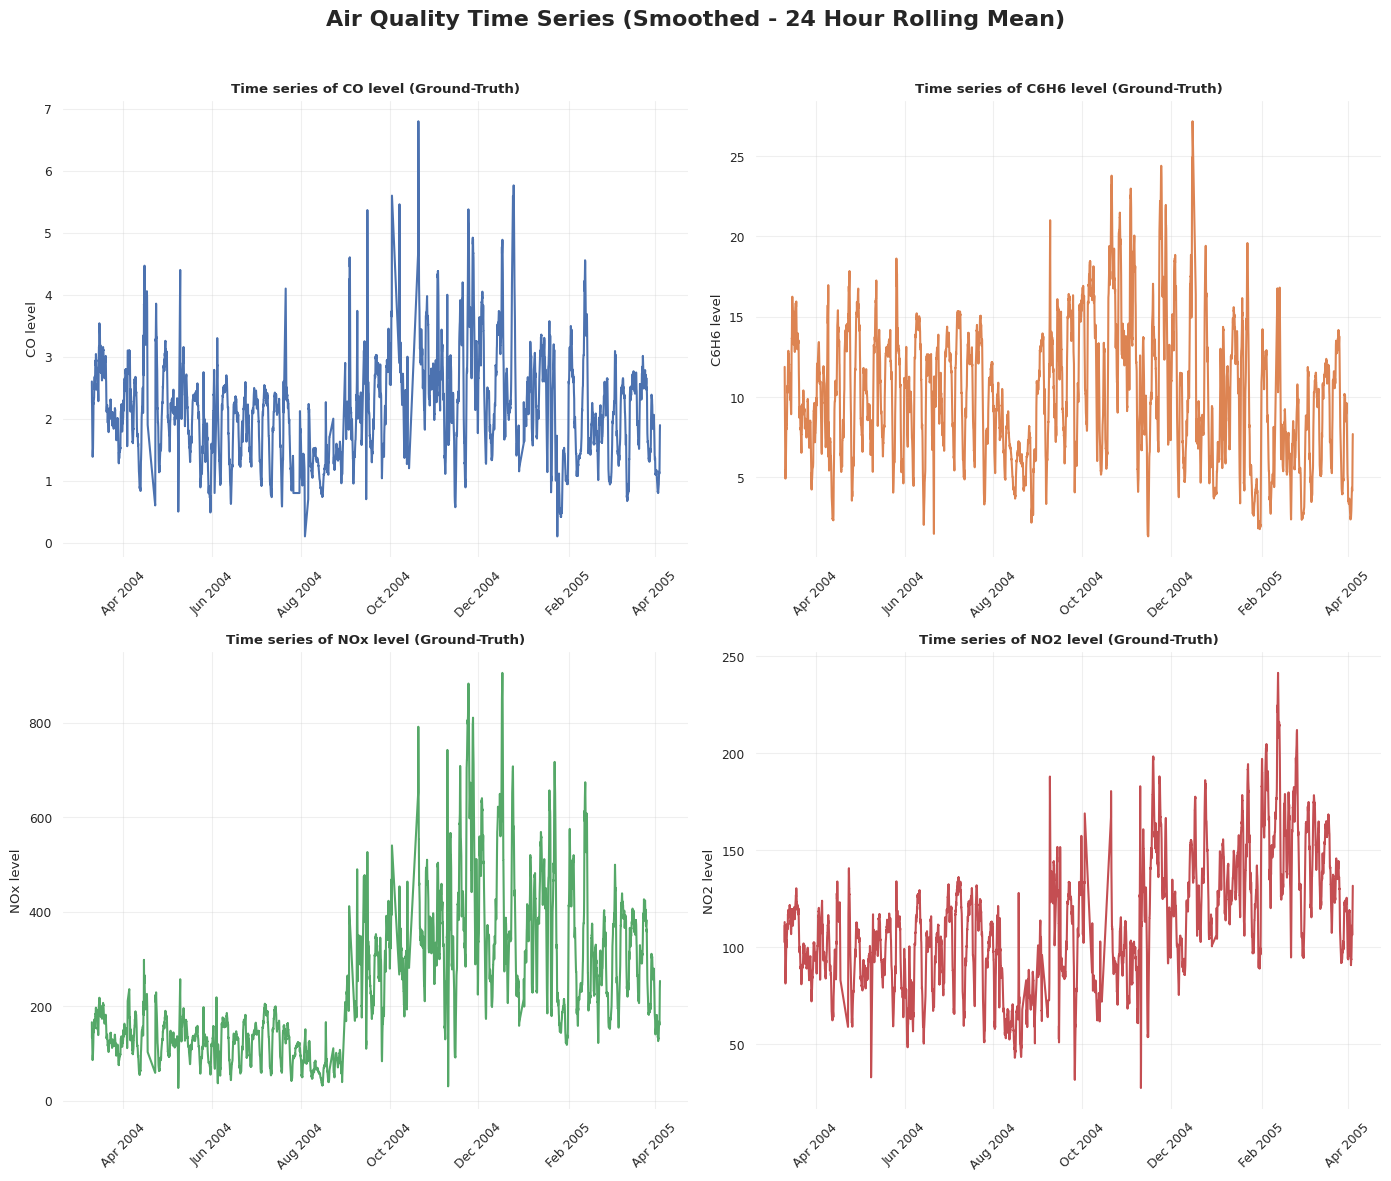

In [ ]:
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Air Quality Time Series (Smoothed - 24 Hour Rolling Mean)",
             fontsize=16, weight='bold', y=0.98)

colors = sns.color_palette("deep", 4)

pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
titles = ["CO", "C6H6", "NOx", "NO2"]

for i in range(4):
    r, c = divmod(i, 2)

    # Rolling mean smoothing with a window of 24 hours
    co_smooth = air_quality_df[pollutants[i]].rolling(24, min_periods=1).mean()

    sns.lineplot(
        x=air_quality_df.index,
        y=co_smooth,
        ax=ax[r, c],
        linewidth=1.5,
        color=colors[i]
    )

    ax[r, c].set_title(f"Time series of {titles[i]} level (Ground-Truth)", weight="bold")
    ax[r, c].set_xlabel("")
    ax[r, c].set_ylabel(f"{titles[i]} level")

    ax[r, c].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax[r, c].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax[r, c].tick_params(axis='x', rotation=45)

    ax[r, c].grid(True, alpha=0.3)

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Box Plot - Pollutant level (Ground Truth) and descriptive statistics

           count        mean         std       min        25%         50%  \
CO(GT)    7674.0    2.152750    1.453252  0.100000   1.100000    1.800000   
C6H6(GT)  8991.0   10.082993    7.449640  0.149048   4.436942    8.239851   
NOx(GT)   7718.0  246.881252  212.971224  2.000000  98.000000  179.800000   
NO2(GT)   7715.0  113.075515   48.359250  2.000000  78.000000  109.000000   

                 75%          max      variance  skewness  missing_values  
CO(GT)      2.900000    11.900000      2.111941  1.369753            1683  
C6H6(GT)   13.988478    63.741476     55.497134  1.361480             366  
NOx(GT)   326.000000  1479.000000  45356.742161  1.715842            1639  
NO2(GT)   142.000000   339.700000   2338.617073  0.621408            1642  


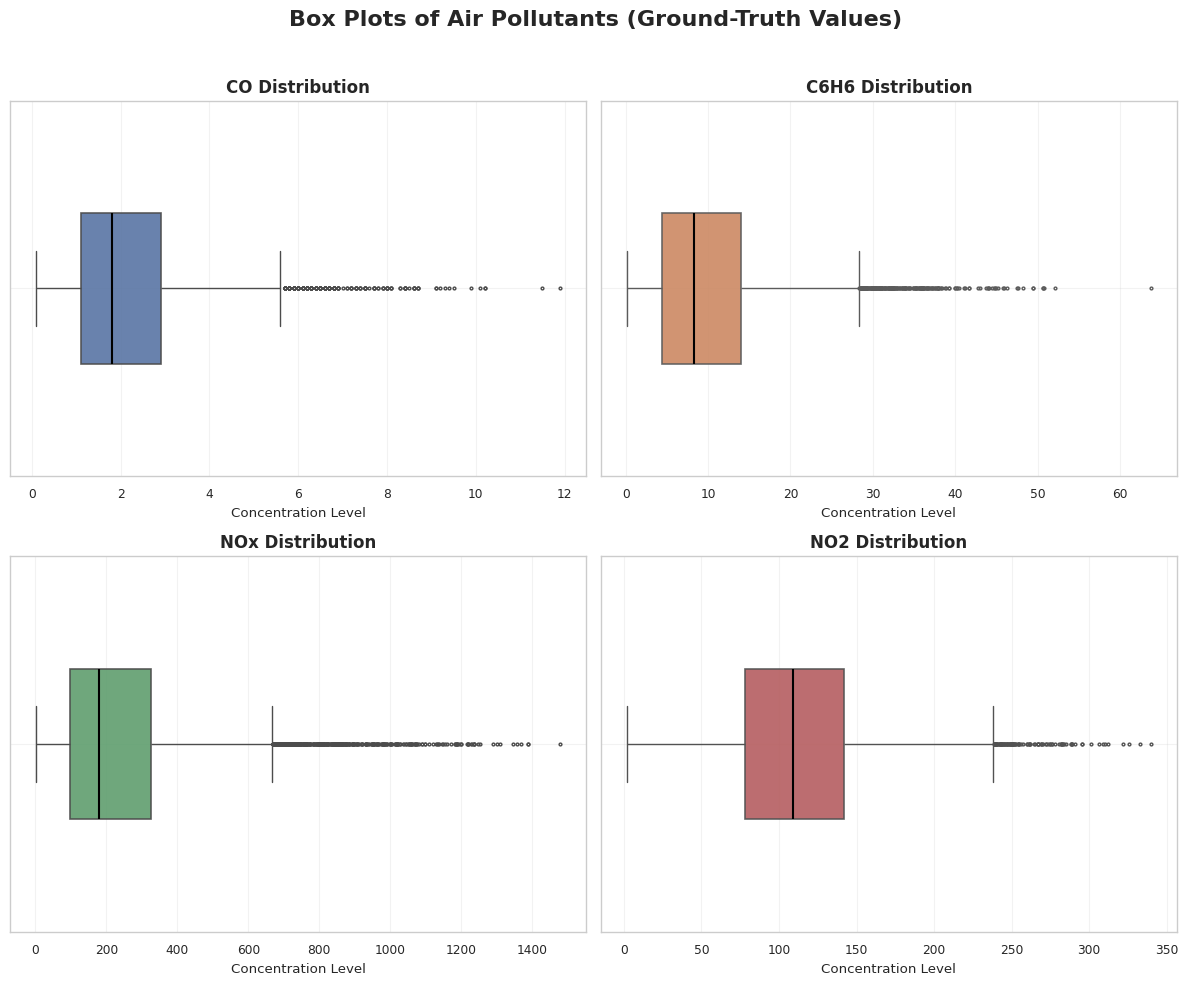

In [ ]:
sns.set_theme(style="whitegrid", context="paper")
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Box Plots of Air Pollutants (Ground-Truth Values)",
             fontsize=16, weight='bold', y=0.98)
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
titles = ["CO", "C6H6", "NOx", "NO2"]
colors = sns.color_palette("deep", 4)
for i, (pollutant, title, color) in enumerate(zip(pollutants, titles, colors)):
    r, c = divmod(i, 2)
    sns.boxplot(
        x=air_quality_df[pollutant],
        ax=ax[r, c],
        color=color,
        width=0.4,
        fliersize=2,# smaller outliers
        linewidth=1.2,
        boxprops=dict(alpha=0.9),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1)
    )
    ax[r, c].set_title(f"{title} Distribution", fontsize=12, weight="bold")
    ax[r, c].set_xlabel("Concentration Level")
    ax[r, c].grid(True, alpha=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.96])

def pollutant_descriptive_stats(df,pollutants):
    stats = df[pollutants].describe().T
    stats["variance"] = df[pollutants].var()
    stats["skewness"] = df[pollutants].skew()
    stats["missing_values"] = df[pollutants].isna().sum()
    return stats
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
stats_table = pollutant_descriptive_stats(air_quality_df, pollutants)
print(stats_table)

- From the descrptive statistics its evident that "CO(GT)", "C6H6(GT)", "NOx(GT)" are heavily right skewed , while "NO2(GT)" is moderately right skewed.
- This indicates most pollutant levels are low/moderate with very few high pollutant spikes.


## Probability Distribution

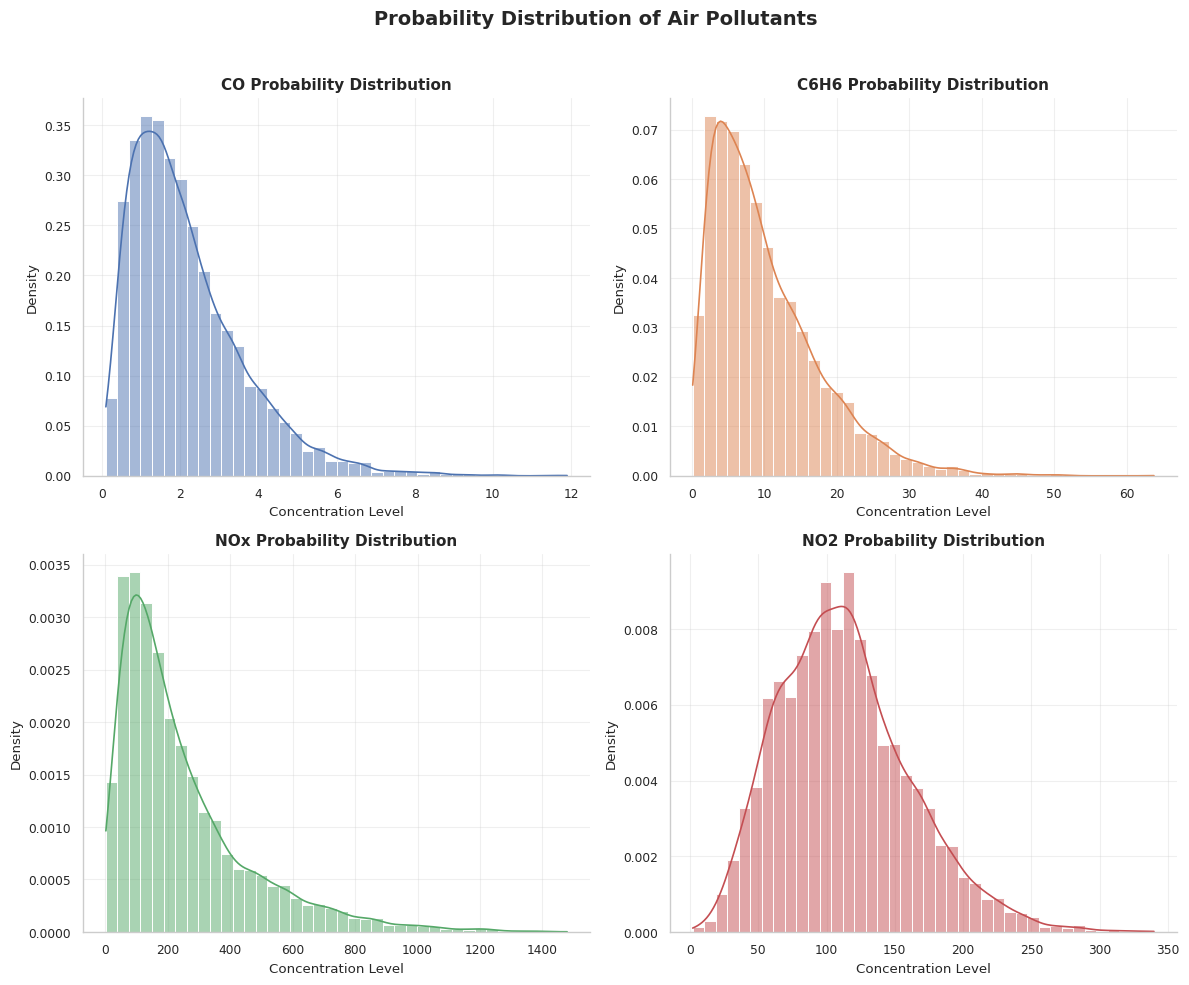

In [ ]:
sns.set_theme(style="whitegrid", context="paper")
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Probability Distribution of Air Pollutants",
             fontsize=14, weight='bold', y=0.98)
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
titles = ["CO", "C6H6", "NOx", "NO2"]
colors = sns.color_palette("deep", 4)

for i, (pollutant, title, color) in enumerate(zip(pollutants, titles, colors)):
    r, c = divmod(i, 2)
    sns.histplot(
        air_quality_df[pollutant].dropna(),   # remove missing values
        kde=True,                               # smooth density curve
        stat="density",                         # probability density
        bins=40,
        color=color,
        ax=ax[r, c]
    )
    ax[r, c].set_title(f"{title} Probability Distribution", fontsize=11, weight="bold")
    ax[r, c].set_xlabel("Concentration Level")
    ax[r, c].set_ylabel("Density")
    ax[r, c].grid(True, alpha=0.3)
sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

- The Probability distribution graph matches with the skewness parameter computed in above section.
- This confirms that most pollutant levels are low/moderate with very few high pollutant spikes.

## Heatmap

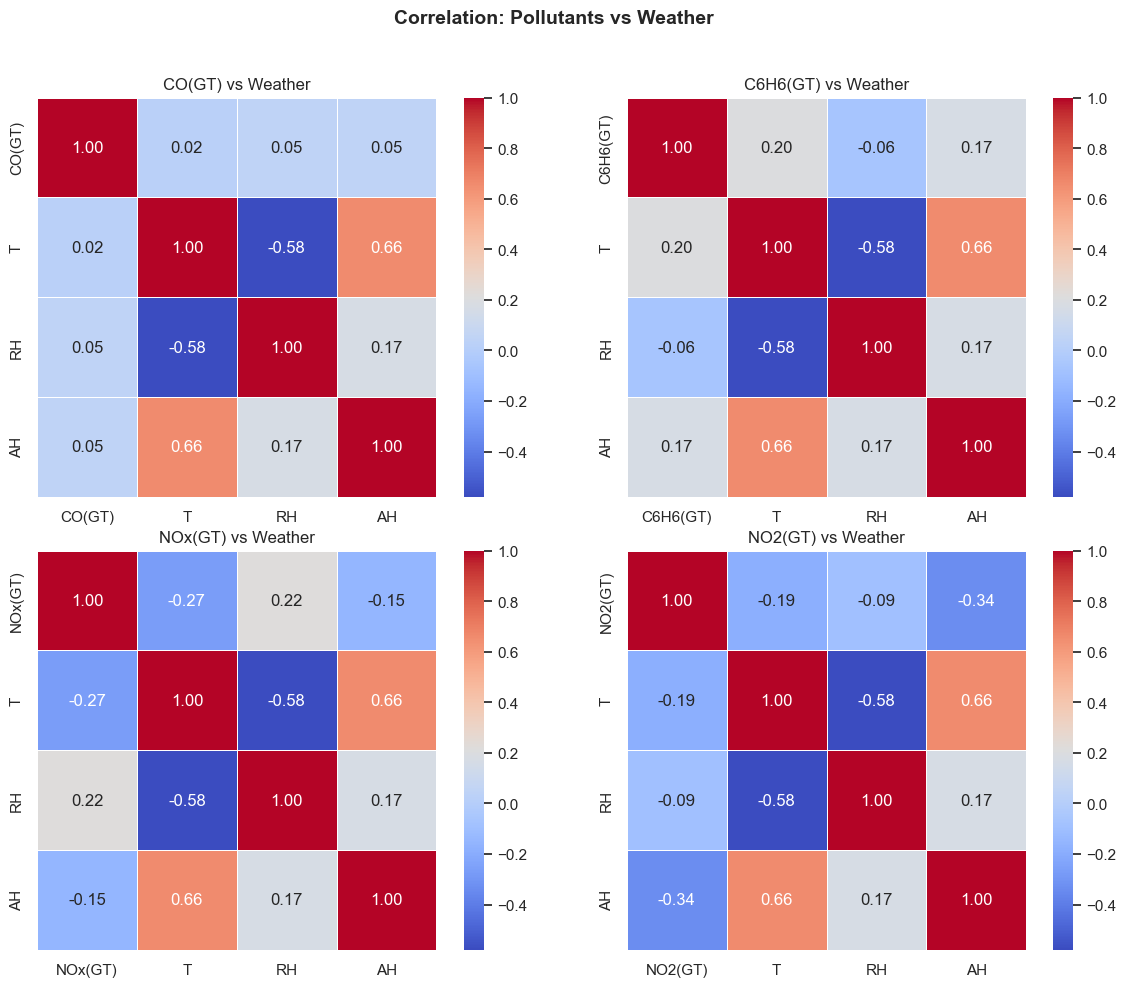

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Correlation: Pollutants vs Weather", fontsize=14, weight='bold')

pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
weather = ["T", "RH", "AH"]

for i, pollutant in enumerate(pollutants):
    r, c = divmod(i, 2)

    # Correlation between one pollutant + weather variables
    corr = air_quality_df[[pollutant] + weather].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        square=True,
        #cbar=False,        # remove extra colorbars for cleaner subplot
        linewidths=0.5,
        ax=ax[r, c]
    )

    ax[r, c].set_title(f"{pollutant} vs Weather")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Conclusions from the above plot :
 - CO is almost independent of weather.
- C6H6 slightly increase with temperature , but it has overall weak weather dependence.
- NOx decreases when temperature rises, indicating better dispersion and slightly increases with humidity indicating possible trapping of this pollutant. Weather has some but not strong influence on NOx.

- NO2 decreases with moisture.Weather affects NO2 more than CO, C6H6, NOx.
NO₂ → forms nitric acid (HNO₃) on wet surfaces / droplets.This removes NO₂ from the air and is very much evident from the data.

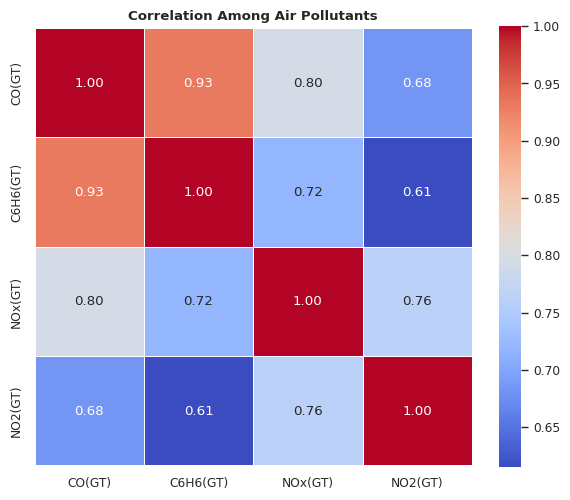

In [ ]:
# Select pollutant columns
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

# Compute correlation matrix
corr = air_quality_df[pollutants].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,        # show correlation values
    cmap="coolwarm",   # color map (red = positive, blue = negative)
    fmt=".2f",         # 2 decimal places
    square=True,
    linewidths=0.5
)

plt.title("Correlation Among Air Pollutants",weight="bold")
plt.tight_layout()
plt.show()

## Pollutant-wise Interpretation

### 1. CO vs C6H6 → $r = 0.93$ (Very strong positive)

- When CO increases → C6H6 almost always increases  
- Near-perfect co-movement  
- Both are combustion-related pollutants (vehicle exhaust, fuel burning)  

**Conclusion:** Same dominant source (traffic/fuel combustion)

---

### 2. CO vs NOx → $r = 0.80$ (Strong positive)

- CO and NOx rise together strongly  
- Suggests shared emission process → high-temperature combustion  

**Conclusion:** Traffic / engine emission link

---

### 3. CO vs NO2 → $r = 0.68$ (Moderate–strong positive)

- Related but weaker than CO–NOx  
- NO₂ partly forms secondarily via oxidation:

$$
\text{NO} \rightarrow \text{NO}_2
$$

**Conclusion:** Still traffic-driven but with atmospheric chemistry influence

---

### 4. C6H6 vs NOx → $r = 0.72$ (Strong positive)

- Benzene and NOx often rise together  
- Indicates vehicle + fuel evaporation + combustion influence  

---

### 5. C6H6 vs NO2 → $r = 0.61$ (Moderate positive)

- Weakest among pairs but still meaningful  
- NO₂ partly secondary → less tightly linked  

---

### 6. NOx vs NO2 → $r = 0.76$ (Strong positive)

- Expected physically: NO₂ is part of NOx system  

Nitrogen oxide chemistry:

$$
\text{NO} + \text{O}_3 \rightarrow \text{NO}_2
$$

**Conclusion:** Shows normal atmospheric nitrogen oxide chemistry
